# Boosting Techniques Assignment
Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.
- Boosting is an ensemble learning technique that combines multiple weak learners to create a strong predictive model. A weak learner is a model that performs only slightly better than random guessing, such as a shallow decision tree.

Boosting works by training models sequentially. Each new model focuses on correcting the mistakes made by the previous models. The final prediction is obtained by combining the predictions of all the models, usually through weighted voting (classification) or weighted averaging (regression).

 - Advantages:
    - Improves prediction accuracy.
   - Reduces bias.
   - Works well for complex datasets.
   - Often achieves better performance than a single model.


Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
| AdaBoost                                      | Gradient Boosting                                              |
| --------------------------------------------- | -------------------------------------------------------------- |
| Trains models sequentially.                   | Trains models sequentially.                                    |
| Gives higher weight to misclassified samples. | Fits the next model on the residual errors of previous models. |
| Adjusts sample weights after each iteration.  | Uses gradient descent to minimize a loss function.             |
| Mainly used for classification.               | Used for both classification and regression.                   |
| Simpler and faster.                           | More flexible and accurate for complex problems.               |


Question 3: How does regularization help in XGBoost?
 - Regularization helps XGBoost reduce overfitting by controlling the complexity of the model.

 - XGBoost uses:

   - L1 Regularization (Lasso): Removes unnecessary features by shrinking some weights to zero.
   - L2 Regularization (Ridge): Reduces the magnitude of model weights.

- Benefits:
  - Prevents overfitting.
  - Improves generalization.
  - Produces simpler models.
  - Improves prediction accuracy on unseen data.

Question 4: Why is CatBoost considered efficient for handling categorical data?
 - CatBoost is specifically designed to handle categorical features without requiring manual encoding techniques such as One-Hot Encoding.

  - Advantages:

    - Automatically processes categorical variables.
    - Reduces preprocessing effort.
    - Minimizes overfitting using ordered boosting.
    - Produces high accuracy on datasets with many categorical features.
    - Handles missing values effectively.

  Because of these features, CatBoost performs exceptionally well on real-world business datasets.

Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?
- Boosting techniques are preferred when high prediction accuracy is required.

- Examples include:

  - Credit card fraud detection
  - Loan default prediction
  - Medical diagnosis
  - Customer churn prediction
  - Recommendation systems
  - Spam email detection
  - Stock market prediction
  - Insurance claim prediction

 Boosting is preferred because it focuses on correcting previous errors, leading to higher predictive performance than bagging in many applications.



In [1]:
# Question 6: AdaBoost Classifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [3]:
# Question 7: Gradient Boosting Regressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 Score
print("R² Score:", r2_score(y_test, y_pred))

HTTPError: HTTP Error 403: Forbidden

In [4]:
# Question 8: XGBoost Classifier with GridSearchCV
# Install XGBoost (only once in Colab)
!pip install xgboost

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parameter Grid
params = {
    "learning_rate":[0.01,0.1,0.2],
    "max_depth":[3,5],
    "n_estimators":[50,100]
}

model = XGBClassifier(eval_metric="logloss")

grid = GridSearchCV(model, params, cv=3)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test,pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.956140350877193


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


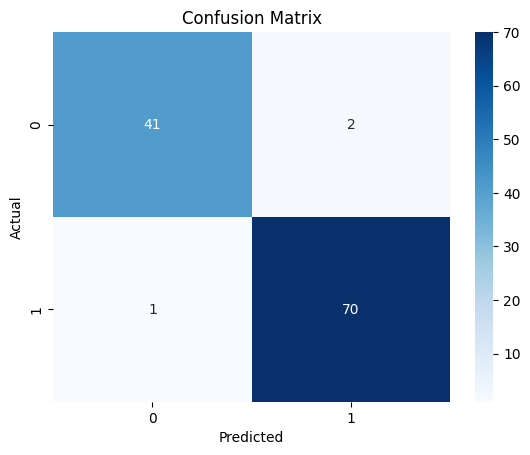

In [5]:
# Question 9: CatBoost Classifier with Confusion Matrix
# Install CatBoost
!pip install catboost

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = CatBoostClassifier(verbose=0)

model.fit(X_train,y_train)

pred = model.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Question 10: Loan Default Prediction using Boosting Techniques
- 1. Data Preprocessing

    - Remove duplicate records.
    - Handle missing values using mean, median, or mode imputation.
    - Encode categorical variables. If using CatBoost, categorical features can be used directly.
    - Scale numerical features if required.
    - Handle class imbalance using techniques such as SMOTE or class weighting.

 2. Choice of Boosting Algorithm

    - AdaBoost: Suitable for simple datasets with fewer features.
    - XGBoost: Preferred for high accuracy, large datasets, and complex relationships.
    - CatBoost: Best when the dataset contains many categorical variables and missing values.

  For this problem, CatBoost is the preferred choice because the dataset contains both numeric and categorical features and includes missing values.

 3. Hyperparameter Tuning
  Use GridSearchCV or RandomizedSearchCV to tune:

    - Number of estimators
    - Learning rate
    - Maximum tree depth
    - Regularization parameters
    - Subsample ratio

 4. Evaluation Metrics
  Since loan default prediction is an imbalanced classification problem, use:

   - Precision
   - Recall
   - F1-score
   - ROC-AUC Score
   - Confusion Matrix

  These metrics provide a better assessment than accuracy alone.

5. Business Benefits

  - Identifies high-risk customers before loan approval.
  - Reduces financial losses due to defaults.
  - Improves decision-making in credit approval.
  - Enhances risk management.
  - Increases profitability while maintaining customer satisfaction.